In [58]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Method 1: Print a formatted list of all registered environments
gym.pprint_registry()

In [16]:
# Creating an Environment
env_name = 'FrozenLake-v1'
env = gym.make(env_name, is_slippery = False)

# Number of states and actions
state_space = env.observation_space.n
action_space = env.action_space.n

print(f"Environment: {env_name}")
print(f"State space: {state_space}")
print(f"Action space: {action_space}")

Environment: FrozenLake-v1
State space: 16
Action space: 4


In [37]:
# Function to reset env
def reset():
    """
    env.reset() : return a tuple of two values (start_state(0), info ) ----> info = {}, ddictionary of meta data mostly empty in case of reset
    """
    state, info = env.reset()
    return state

# take step/action
def move(action):
    """
    env.step(): return 5 values
        next_state = new state in env after taking an action
        reward: reward received
        terminated: if goal is achieved (boolean value)
        trunacted: if episode ended because of constraints.
        info: debugg data       
    """
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    return state, reward, done, info

 ### Q-Learning Implementation

In [64]:
ALPHA  = 0.1 # learning rate
GAMMA = 0.99 # discount factor
EPSILON = 1
EPSILON_min = 0.01
EPSILON_decay = 0.9995

# Q-table : initialize all tio zeroes
q_table = np.zeros((state_space, action_space))

# Metrics
episode_rewards = []
episode_lengths = []

In [30]:
def select_action(state, training =True):
    """ greedy action selection"""

    if training and np.random.random() < EPSILON:
        return np.random.randint(action_space)
    else:
        return np.argmax(q_table[state]) # returns the position of highest value. (in our case, action-space)

In [49]:
def update(state, action, reward, next_state, done):
    """Q-Learning update"""
    current_q = q_table[state, action]

    if done:
        td_target = reward
    else:
        max_next_q = np.max(q_table[next_state])
        td_target = reward + GAMMA*max_next_q

    td_error = td_target - current_q
    q_table[state, action] += ALPHA* td_error
    

In [65]:
NUM_EPISODE = 10000
MAX_STEP = 100

print("\n" + "="*60)
print("TRAINING Q-LEARNING AGENT")
print("="*60)

for episode in range(NUM_EPISODE):
    state, _ = env.reset()
    total_reward = 0
    steps = 0

    for step in range(MAX_STEP):

        # 1. Decide on the action to take
        action = select_action(state)

        # 2. new state and reward based on action taken
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # 3. update the q_table
        update(state, action, reward, next_state, done)

        # 4. record metrics
        total_reward += reward
        steps += 1

        # 5 update state to new state
        state = next_state
        if done:
            break

    # Devcay the epsilon. Move from eploration to eploitation.
    EPSILON = max(EPSILON_min, EPSILON * EPSILON_decay)
    
    episode_rewards.append(total_reward)
    episode_lengths.append(steps)
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(episode_rewards[-100:])
        print(f"Episode {episode+1}/{NUM_EPISODE} | "
              f"Avg Reward: {avg_reward:.3f} | "
        f"ε: {EPSILON:.3f}")

print("\n✅ TRAINING COMPLETE!")
print(f"Success rate: {np.mean(episode_rewards[-100:])*100:.1f}%\n")


TRAINING Q-LEARNING AGENT
Episode 100/10000 | Avg Reward: 0.000 | ε: 0.951
Episode 200/10000 | Avg Reward: 0.040 | ε: 0.905
Episode 300/10000 | Avg Reward: 0.020 | ε: 0.861
Episode 400/10000 | Avg Reward: 0.070 | ε: 0.819
Episode 500/10000 | Avg Reward: 0.050 | ε: 0.779
Episode 600/10000 | Avg Reward: 0.090 | ε: 0.741
Episode 700/10000 | Avg Reward: 0.050 | ε: 0.705
Episode 800/10000 | Avg Reward: 0.180 | ε: 0.670
Episode 900/10000 | Avg Reward: 0.250 | ε: 0.638
Episode 1000/10000 | Avg Reward: 0.160 | ε: 0.606
Episode 1100/10000 | Avg Reward: 0.320 | ε: 0.577
Episode 1200/10000 | Avg Reward: 0.260 | ε: 0.549
Episode 1300/10000 | Avg Reward: 0.280 | ε: 0.522
Episode 1400/10000 | Avg Reward: 0.380 | ε: 0.496
Episode 1500/10000 | Avg Reward: 0.420 | ε: 0.472
Episode 1600/10000 | Avg Reward: 0.450 | ε: 0.449
Episode 1700/10000 | Avg Reward: 0.490 | ε: 0.427
Episode 1800/10000 | Avg Reward: 0.490 | ε: 0.406
Episode 1900/10000 | Avg Reward: 0.470 | ε: 0.387
Episode 2000/10000 | Avg Reward:

### Testing the trained Agent

In [69]:
TEST_EPISODES = 100
test_rewards = []

for episode in range(TEST_EPISODES):

    state, _ = env.reset()
    total_reward = 0

    while True:
        action = select_action(state, training =False)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        total_reward += reward
        state = next_state

        if done:
            break
    test_rewards.append(total_reward)
print(f"Test success rate: {np.mean(test_rewards)*100:.1f}%")
    

Test success rate: 100.0%


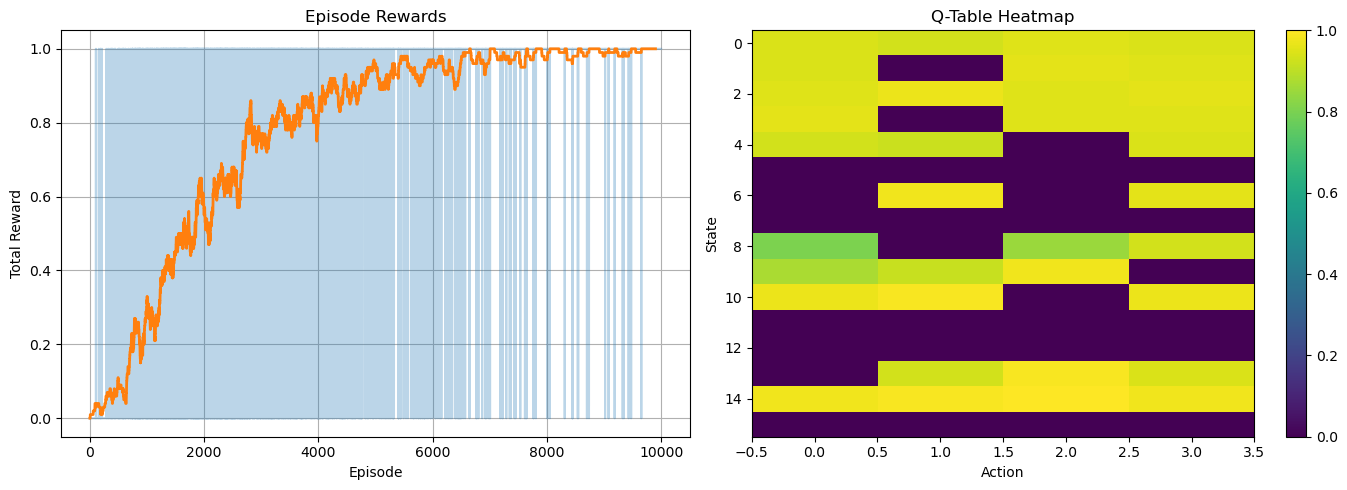

In [71]:
""" Training Curves"""

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,5))

# Reward
ax1.plot(episode_rewards, alpha = 0.3)
moving_avg = np.convolve(episode_rewards, np.ones(MAX_STEP)/MAX_STEP, mode = 'valid')
ax1.plot(moving_avg, linewidth=2)
ax1.set_title('Episode Rewards')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.grid(True)

# Q-table heatmap
im = ax2.imshow(q_table, cmap='viridis', aspect='auto')
ax2.set_title('Q-Table Heatmap')
ax2.set_xlabel('Action')
ax2.set_ylabel('State')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig('q_learning_results.png')
plt.show()

In [75]:
""" Learned Policy """

actions = ['←', '↓', '→', '↑']
print("\nLearned Policy (FrozenLake 4x4):")
print("="*30)

for i in range(4):
    row = ''
    for j in range(4):
        state = i * 4 +j
        best_action = np.argmax(q_table[state])
        row  += f"{actions[best_action]} "
    print(row)
print("="*30)

np.savez('q_agent.npz', q_table=q_table)
print("Saved")


Learned Policy (FrozenLake 4x4):
→ → ↓ ← 
↑ ← ↓ ← 
↑ → ↓ ← 
← → → ← 
Saved
